# AO mode landscape: which wavefront sensor wins, where

Every HISPEC target has to be handed to *some* AO mode, and the best choice
depends on two things at once: how bright the star is, and how red it is. A
1500 K L dwarf with H = 10 is V ~ 22 -- hopeless for a visible wavefront
sensor, but comfortable for a pyramid running on the H-band light. A 5800 K
G star at the same H magnitude is V ~ 11, where the Shack-Hartmann is fine.

This notebook maps that trade over the (T$_{eff}$, magnitude) plane:

1. compute, for each candidate AO mode, the Strehl it delivers across the plane
2. take the per-pixel winner to get **mode regions** and the **achievable Strehl**
3. overlay the real target populations that have to be observed
4. compare **candidate mode suites** -- the actual design question: what does
   adding a pyramid mode, or moving it from J to H, buy you?

The physics all comes out of `specsim`: `load_WFE` for the tabulated wavefront
error per mode, `Star.magnitude_in_band` for the colour conversion between each
mode's native band and the science band, and
`calc_strehl_marechal`/`tt_to_strehl` for the two Strehl terms. Nothing here
re-implements specsim -- it drives it over a grid.

> **Ported from** `_pyramid_sims/plot_ao_landscape.py` (`get_best_aomode` +
> `plot_planets_ao_modes`). Section 12 lists what changed and why.

## 1. Setup

Paths follow the convention in `examples/ao_mode_cases.py`: relative to the
specsim tree for anything shipped with it, anchored explicitly for data that
lives outside it (the full PHOENIX/Sonora grids and the target catalogues).

In [1]:
%matplotlib inline

import os
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path

try:
    _root = str(Path(__file__).resolve().parent.parent)
except NameError:  # running as a notebook; assume cwd is examples/
    _root = str(Path.cwd().parent)
sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
from matplotlib.collections import QuadMesh
from scipy import interpolate, ndimage

from specsim.aosystem import load_WFE
from specsim.bandpass import Bandpass
from specsim.config import simulate_from_config
from specsim.functions import calc_strehl_marechal, tt_to_strehl
from specsim.star import Star


# Data outside the specsim tree, anchored here so this runs from any folder.
def _sibling(*parts):
    return os.path.join(_root, '..', '..', *parts) + os.sep


# The bundled grids only ship 2300 K and 5800 K; a landscape needs the full ones.
PHOENIX_FOLDER = _sibling('_data', 'phoenix')      # PHOENIX, Teff >= 2300 K
SONORA_FOLDER  = _sibling('_data', 'sonora')       # Sonora, Teff < 2300 K
POP_DIR        = _sibling('_data', 'populations')  # target catalogues, section 6
AO_STAR_DIR    = _sibling('HISPEC', 'DesignAnalyses', 'SPEC', '_pyramid_sims')  # ultracool.out

HAVE_MODEL_GRID = os.path.isdir(PHOENIX_FOLDER) and os.path.isdir(SONORA_FOLDER)

# np.loadtxt is noisy about the comment lines in the zeropoint and colour
# tables, once per call and harmlessly.
warnings.filterwarnings('ignore', message='Input line .* contained no data')

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110,
                     'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#0b0b0b',
                     'xtick.color': '#898781', 'ytick.color': '#898781',
                     'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb'})

### Palette

Colours are assigned by the *job* each one does, not by series order:

| Channel | Encoding | Why |
|---|---|---|
| Achievable Strehl (the fill) | **sequential** blue ramp, light->dark | continuous magnitude: one hue, never a rainbow |
| Signed Strehl difference | **diverging** blue<->red, gray midpoint | polarity, so "no change" reads as nothing |
| AO mode identity | **direct labels + hairline boundaries** | see the note below |
| Target populations | categorical slots orange / aqua / violet | identity, 3 series |

**Why mode identity is not a fill colour.** The original figure filled each
mode region with a categorical hue. Six different modes appear across the
suites compared in section 8, and a region map is scored on the *all-pairs*
colour-separation gate (like a choropleth) rather than the adjacent-pairs one.
Only 2 of the 70 possible four-hue subsets of the reference palette clear
all-pairs in both light and dark mode, and both only in the warn band -- past
three or four slots the rule is to facet or drop the hue channel, not to hunt
for more hues. So the fill carries achieved Strehl (strictly more information
than "which mode won") and mode identity moves to direct labels plus
surface-coloured boundaries. Colour is then never the only channel carrying
mode identity.

The overlay trio was picked by running the six checks over every 3-subset with
blue excluded (it is the fill hue). orange / aqua / violet is the best clean
pass: worst all-pairs CVD dE 9.2 against a target of 8, worst normal-vision
dE 24.6 against a floor of 15, in both light and dark mode.

In [2]:
# --- chrome & ink -------------------------------------------------------
SURFACE   = '#fcfcfb'
INK       = '#0b0b0b'
INK_2     = '#52514e'
GRIDLINE  = '#e1e0d9'

# --- sequential: achievable Strehl -------------------------------------
# Blue ramp, steps 100 -> 700. One hue, monotone in OKLCH lightness
# (L 0.905 -> 0.338), so it reads as a ramp rather than as categories.
SEQ_BLUE = ['#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7',
            '#3987e5', '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b']
STREHL_CMAP = mcolors.LinearSegmentedColormap.from_list('strehl_blue', SEQ_BLUE)

# --- diverging: Strehl gained / lost between two suites ----------------
# Blue <-> red with the neutral gray midpoint; equal steps per arm.
DELTA_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'strehl_delta', ['#e34948', '#ee8b8a', '#f0efec', '#86b6ef', '#2a78d6'])

# --- categorical: target populations -----------------------------------
POP_STYLE = {
    'planet_hosts': dict(color='#eb6834', marker='s', size=9,  label='Exoplanet hosts'),
    'brown_dwarfs': dict(color='#1baf7a', marker='o', size=7,  label='VLM stars & brown dwarfs'),
    'red_ao_star':  dict(color='#4a3aa7', marker='*', size=55, label='Has red AO star nearby'),
}

## 2. The scene

One `Simulate` supplies everything the landscape needs: the WFE table paths,
the observing conditions those tables are indexed by (seeing and zenith
angle), the science bandpass whose centre wavelength sets the Strehl, and the
telescope diameter that turns a tip-tilt residual into a Strehl term.

The band is pinned at build time rather than read from the `.cfg`, because the
whole landscape -- axis labels, the Strehl the modes are ranked on -- is
defined in it.

In [3]:
CONFIG    = os.path.join(_root, 'configs', 'hispec_snr.cfg')
SCI_BAND  = 'H'      # band the landscape's magnitude axis is in
SEEING    = 'good'   # 'good' | 'average' | 'bad'
ZENITH    = 30       # deg; WFE tables are tabulated at 0, 30, 45, 60

sim = simulate_from_config(CONFIG, filt_band=SCI_BAND)
if HAVE_MODEL_GRID:
    sim.set_star(phoenix_folder=PHOENIX_FOLDER, sonora_folder=SONORA_FOLDER)
sim.set_atmosphere(seeing_set=SEEING, zenith_angle=ZENITH)

print('\nscience band : %s (centre %.0f nm)' % (sim.filt.band, sim.filt.center_wavelength))
print('telescope    : %.1f m' % sim.ao_system.diameter_m)
print('conditions   : %s seeing, %g deg zenith' % (sim.atmosphere.seeing_set, sim.zenith_angle))

Auto AO Mode
AO mag is 11.38 in V band (from H = 10.0, Teff = 5800K)
AO mode chosen: NGS_SH
HO WFE is 141
tt dynamic is 2.97


Auto AO Mode
AO mag is 11.38 in V band (from H = 10.0, Teff = 5800K)
AO mode chosen: NGS_SH
HO WFE is 141
tt dynamic is 2.97


Auto AO Mode
AO mag is 11.38 in V band (from H = 10.0, Teff = 5800K)
AO mode chosen: NGS_SH
HO WFE is 132
tt dynamic is 2.94



science band : H (centre 1652 nm)
telescope    : 10.0 m
conditions   : good seeing, 30 deg zenith


Which modes the instrument's WFE tables actually contain, and the band each is
tabulated in -- that band is what forces the colour conversion in section 3.

In [4]:
WFE = load_WFE(sim.ao_system.ho_wfe_file, sim.ao_system.tt_dynamic_file,
               sim.zenith_angle, sim.atmosphere.seeing_set)

print('%-14s %-6s %-22s %s' % ('mode', 'band', 'HO WFE [nm] @ mag 1/10/18',
                               'tt [mas] @ mag 1/10/18'))
for mode, d in WFE.items():
    at = lambda arr: '/'.join('%.0f' % np.interp(m, d['ho_mag'], arr) for m in (1, 10, 18))
    print('%-14s %-6s %-22s %s' % (mode, d['band'], at(d['ho_wfe']), at(d['tt_wfe'])))

TABLE_MAGS = WFE[next(iter(WFE))]['ho_mag']
print('\ntabulated on %d magnitudes, %.2f to %.1f'
      % (len(TABLE_MAGS), TABLE_MAGS[0], TABLE_MAGS[-1]))

mode           band   HO WFE [nm] @ mag 1/10/18 tt [mas] @ mag 1/10/18
LGS_100H       H      192/192/195            3/3/18
LGS_100J       J      192/192/194            3/3/18
LGS_STRAP      V      192/192/192            3/3/16
NGS_SH         V      130/131/644            3/3/31
PyWFS_100J     J      130/167/1000           3/7/1000
PyWFS_80J      J      130/178/1000           3/8/1000
PyWFS_100H     H      130/197/1000           3/8/1000
PyWFS_80H      H      130/214/1000           3/9/1000

tabulated on 24 magnitudes, 0.01 to 23.0


## 3. Computing the landscape

For one science star (T$_{eff}$, magnitude $m_{sci}$ in the science band) and
one AO mode:

1. the mode's WFE table is indexed by guide-star magnitude **in the mode's own
   band** -- V for `NGS_SH` and `LGS_STRAP`, J or H for the IWA modes;
2. so convert: $m_{band} = m_{sci} - c$, where the colour
   $c = m_{sci} - m_{band}$ comes from synthetic photometry on the star's own
   model spectrum (`Star.magnitude_in_band`);
3. read the HO WFE and tip-tilt residual at $m_{band}$ and turn them into
   $S = S_{HO}(\mathrm{wfe}, \lambda)\,S_{tt}(tt, \lambda, D)$.

Two implementation notes:

- **The output magnitude grid is decoupled from the table's.** The WFE tables
  are tabulated on 24 magnitudes at ~1 mag spacing. Rather than reporting on
  that grid, the WFE is interpolated at whatever grid you ask for, so region
  boundaries are not quantised to 1 mag. (This was a `To Do` in the original.)
- **Guide stars fainter than the table get Strehl 0, not the last row's
  value.** Clamping the faint end would quietly claim mag-23 performance for a
  mag-30 guide star -- exactly the regime cool dwarfs land in once the colour
  shift is applied.

In [5]:
@dataclass
class Landscape:
    "Strehl each AO mode delivers over a (Teff, science-band magnitude) grid."
    ao_modes: list          # mode names, in the order indexed by best_idx
    temps: np.ndarray       # K, (n_temp,)
    mags: np.ndarray        # mag in `band`, (n_mag,)
    strehl: np.ndarray      # (n_temp, n_mode, n_mag)
    band: str               # science band the mags and Strehl are defined in
    colors: dict            # {wfe_band: array over temps} of m_sci - m_wfe_band

    @property
    def best_idx(self):
        "Index into ao_modes of the winning mode, (n_temp, n_mag)."
        return np.argmax(self.strehl, axis=1)

    @property
    def best_strehl(self):
        "Strehl the winning mode delivers, (n_temp, n_mag)."
        return np.max(self.strehl, axis=1)

    @property
    def best_name(self):
        "Name of the winning mode, (n_temp, n_mag)."
        return np.asarray(self.ao_modes)[self.best_idx]

    def strehl_at(self, teff, mag):
        "Bilinearly interpolate best_strehl at scattered (teff, mag) points."
        grid = interpolate.RegularGridInterpolator(
            (self.temps, self.mags), self.best_strehl,
            bounds_error=False, fill_value=np.nan)
        return grid(np.column_stack([np.asarray(teff, float), np.asarray(mag, float)]))

    def save(self, path):
        # One self-describing .npz. The original script saved four separate
        # .npy files whose grids lived only in the filename, so a reader had to
        # re-type the temperature list to interpret the array.
        np.savez(path, ao_modes=np.asarray(self.ao_modes), temps=self.temps,
                 mags=self.mags, strehl=self.strehl, band=str(self.band))

    @classmethod
    def load(cls, path):
        z = np.load(path, allow_pickle=False)
        return cls([str(m) for m in z['ao_modes']], z['temps'], z['mags'],
                   z['strehl'], str(z['band']), {})


def compute_landscape(sim, ao_modes, temps, mags, wfe=None, verbose=False):
    """
    Strehl vs (Teff, science-band magnitude) for each of ao_modes.

    inputs
    ------
    sim : Simulate
        supplies the WFE table paths, conditions, science bandpass, telescope
        diameter, and the StarParams the grid's stars are built from
    ao_modes : list of str
        mode names present in the instrument's WFE tables
    temps : array [K]
        Teff grid; needs a model file present for each value
    mags : array
        magnitude grid, in sim.filt's band
    wfe : dict, optional
        an already-loaded load_WFE() result, to avoid re-reading the tables
    verbose : bool
        print the colour of each star as it goes

    output
    ------
    Landscape
    """
    if wfe is None:
        wfe = load_WFE(sim.ao_system.ho_wfe_file, sim.ao_system.tt_dynamic_file,
                       sim.zenith_angle, sim.atmosphere.seeing_set)

    missing = [m for m in ao_modes if m not in wfe]
    if missing:
        raise ValueError('not in the WFE tables: %s (have: %s)' % (missing, sorted(wfe)))

    wavelength  = sim.filt.center_wavelength
    diameter    = sim.ao_system.diameter_m
    temps, mags = np.asarray(temps, float), np.asarray(mags, float)

    # One Bandpass per *band*, not per mode: NGS_SH and LGS_STRAP are both
    # tabulated in V, and each magnitude_in_band() call on a band outside the
    # loaded model range re-reads the model grid off disk. Built once here and
    # reused across the whole temperature loop.
    wfe_bands  = sorted({wfe[m]['band'] for m in ao_modes})
    bandpasses = {b: Bandpass.load(sim.filter_path, sim.zp_file, b) for b in wfe_bands}

    strehl = np.zeros((len(temps), len(ao_modes), len(mags)))
    colors = {b: np.zeros(len(temps)) for b in wfe_bands}

    for i, teff in enumerate(temps):
        # Only the star's colours matter here, so build a Star straight off the
        # scene's params (which carry the model folders) rather than calling
        # sim.set_star(), which would also re-run AO mode selection and reload
        # the fiber coupling once per temperature.
        star = Star(sim.star.params, teff=teff).load(sim.x, sim.filt)
        # colour is scale-free: m_sci - m_band is the same at any magnitude
        color = {b: star.params.mag - star.magnitude_in_band(bp)
                 for b, bp in bandpasses.items()}
        for b, c in color.items():
            colors[b][i] = c

        for k, mode in enumerate(ao_modes):
            d = wfe[mode]
            m_band = mags - color[d['band']]     # magnitude in the mode's own band
            ho = np.interp(m_band, d['ho_mag'], d['ho_wfe'])
            tt = np.interp(m_band, d['tt_mag'], d['tt_wfe'])
            s = calc_strehl_marechal(ho, wavelength) * tt_to_strehl(tt, wavelength, diameter)
            s[~np.isfinite(s)] = 0
            s[m_band > d['ho_mag'][-1]] = 0      # guide star off the faint end: no lock
            strehl[i, k] = s

        if verbose:
            print('  Teff %5g K  ' % teff + '  '.join(
                '%s-%s %5.2f' % (sim.filt.band, b, color[b]) for b in wfe_bands))

    return Landscape(list(ao_modes), temps, mags, strehl, sim.filt.band, colors)

### The grid

PHOENIX is available at 100 K steps from 2300 K up and Sonora below it, so a
100 K axis costs only time -- about 0.15 s per temperature. The magnitude axis
is ours to choose; 0.2 mag is well inside what the interpolated WFE supports.

In [6]:
if HAVE_MODEL_GRID:
    TEMPS = np.arange(1000, 6001, 100.)       # Sonora below 2300 K, PHOENIX above
else:
    TEMPS = np.array([2300., 5800.])          # only what specsim bundles
    print('!! Full model grids not found. Point PHOENIX_FOLDER / SONORA_FOLDER at')
    print('   your own grids for a real landscape; running on the bundled two Teffs.')

MAGS = np.arange(0, 20.01, 0.2)               # in SCI_BAND

print('grid: %d temperatures (%g-%g K), %d magnitudes (%g-%g)'
      % (len(TEMPS), TEMPS[0], TEMPS[-1], len(MAGS), MAGS[0], MAGS[-1]))

grid: 51 temperatures (1000-6000 K), 101 magnitudes (0-20)


## 4. The cases

This is the design question the notebook exists for. Each case is a candidate
*suite* of AO modes -- the set an observer would actually choose from -- and
its landscape shows what the best of that suite delivers everywhere.

The suites below are the ones tested in the pyramid study: no pyramid at all,
the pyramid taking all of H, the pyramid taking only 80% of H (leaving the
rest for science), and the pyramid in J instead.

Note that a suite is **not** necessarily a superset of the baseline --
`Pyramid 100J` also moves the LGS tip-tilt sensor from H to J -- so the
difference in section 9 can go negative. That is the trade, not a bug.

Add your own by putting another entry in the dict.

In [7]:
CASES = {
    'No pyramid':    ['NGS_SH', 'LGS_100H', 'LGS_STRAP'],
    'Pyramid 100H':  ['NGS_SH', 'PyWFS_100H', 'LGS_100H', 'LGS_STRAP'],
    'Pyramid 80H':   ['NGS_SH', 'PyWFS_80H',  'LGS_100H', 'LGS_STRAP'],
    'Pyramid 100J':  ['NGS_SH', 'PyWFS_100J', 'LGS_100J', 'LGS_STRAP'],
}
BASELINE_CASE = 'No pyramid'   # what section 9 differences everything against

landscapes = {}
for name, modes in CASES.items():
    print('%-18s %s' % (name + ':', ', '.join(modes)))
    landscapes[name] = compute_landscape(sim, modes, TEMPS, MAGS, wfe=WFE)

VMAX = max(float(np.nanmax(l.best_strehl)) for l in landscapes.values())
print('\ndone -- peak Strehl across all suites: %.3f' % VMAX)

No pyramid:        NGS_SH, LGS_100H, LGS_STRAP


Pyramid 100H:      NGS_SH, PyWFS_100H, LGS_100H, LGS_STRAP


Pyramid 80H:       NGS_SH, PyWFS_80H, LGS_100H, LGS_STRAP


Pyramid 100J:      NGS_SH, PyWFS_100J, LGS_100J, LGS_STRAP



done -- peak Strehl across all suites: 0.755


The colours driving all of this, worth a sanity check on their own. A cool
dwarf is enormously fainter in V than in H, which is the whole reason a
pyramid running on H-band light wins at the bottom of the main sequence.

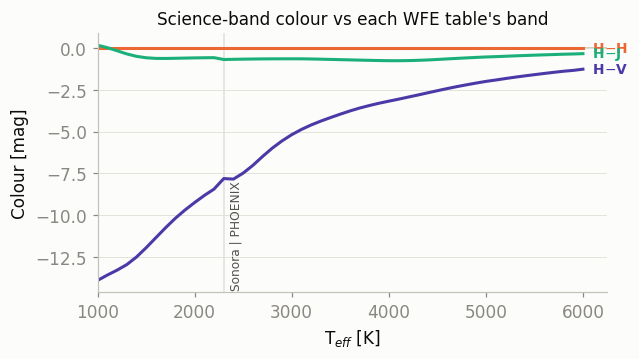

In [8]:
ls0 = landscapes[BASELINE_CASE]
# every band used by any suite, not just the baseline's
all_colors = {b: c for ls in landscapes.values() for b, c in ls.colors.items()}

fig, ax = plt.subplots(figsize=(5.8, 3.4))
for (band, c), col in zip(sorted(all_colors.items()), ['#eb6834', '#1baf7a', '#4a3aa7']):
    ax.plot(ls0.temps, c, lw=2, color=col)
    ax.annotate('  %s$-$%s' % (ls0.band, band), (ls0.temps[-1], c[-1]), color=col,
                fontsize=9, va='center', ha='left', fontweight='bold',
                annotation_clip=False)
ax.axhline(0, color='#c3c2b7', lw=1, zorder=0)
# specsim switches model family here, so a small kink is expected
ax.axvline(2300, color=GRIDLINE, lw=1, zorder=0)
ax.annotate('Sonora | PHOENIX', (2300, ax.get_ylim()[0]), xytext=(4, 3),
            textcoords='offset points', fontsize=8, color=INK_2, rotation=90)
ax.set_xlabel('T$_{eff}$ [K]')
ax.set_ylabel('Colour [mag]')
ax.set_title('Science-band colour vs each WFE table\'s band', fontsize=11, color=INK)
ax.set_xlim(ls0.temps[0], ls0.temps[-1] + 250)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.grid(axis='y', color=GRIDLINE, lw=0.6)
ax.set_axisbelow(True)
fig.tight_layout()

## 5. Diagnostic: Strehl vs guide-star magnitude

Before the 2-D map, the 1-D cuts it is built from. Each panel is one
temperature, each line one mode's Strehl as a function of the *science*
magnitude after the colour shift. Where the lines cross is where the winning
mode changes -- the region boundaries in the map are exactly these crossings.
The gray band underneath is the per-magnitude winner.

The original script opened three separate figures per temperature (24 windows
for eight temperatures). Small multiples on shared axes make the crossings
comparable across temperature, which is the point.

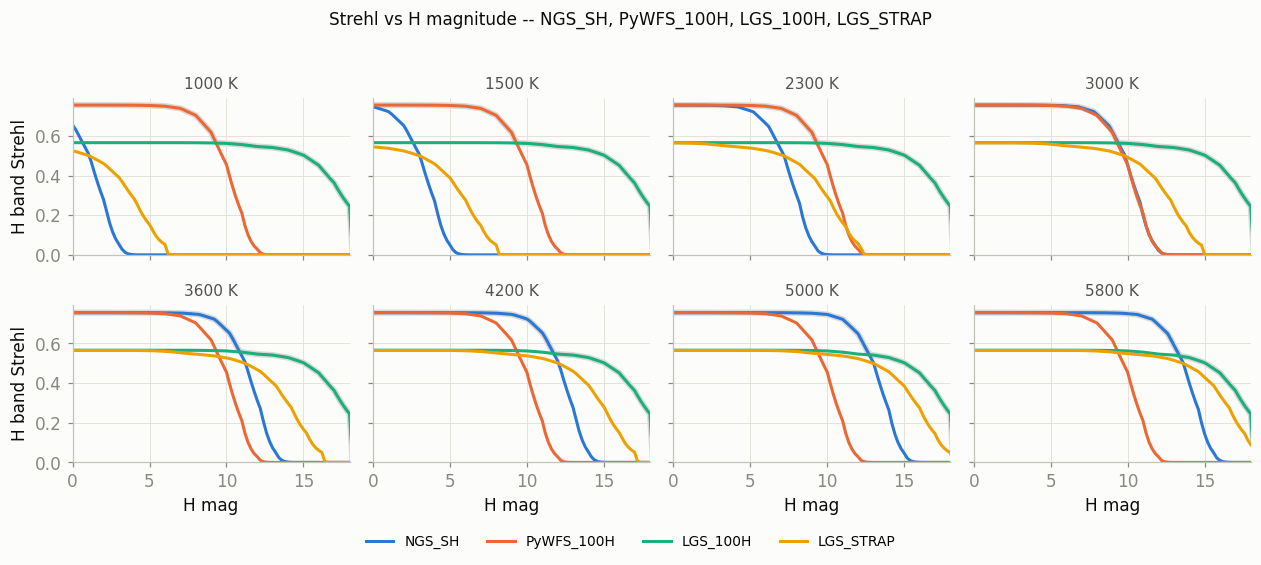

In [9]:
def plot_strehl_cuts(ls, temps_to_show, ncols=4, mag_xlim=(0, 18)):
    "Strehl vs science magnitude, one panel per temperature, one line per mode."
    temps_to_show = [t for t in temps_to_show if np.any(np.isclose(ls.temps, t))]
    if not temps_to_show:
        print('none of the requested temperatures are on the grid')
        return None, None
    n = len(temps_to_show)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(2.9 * ncols, 2.5 * nrows),
                            sharex=True, sharey=True, squeeze=False)
    # Mode identity is a line here, not a region fill, so the adjacent-pairs
    # gate applies and the reference categorical order works as shipped.
    line_colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']

    for ax, teff in zip(axs.ravel(), temps_to_show):
        i = int(np.argmin(np.abs(ls.temps - teff)))
        ax.plot(ls.mags, ls.best_strehl[i], lw=4, color=INK, alpha=0.14, zorder=0)
        for k, mode in enumerate(ls.ao_modes):
            ax.plot(ls.mags, ls.strehl[i, k], lw=2,
                    color=line_colors[k % len(line_colors)], label=mode)
        ax.set_title('%g K' % ls.temps[i], fontsize=10, color=INK_2)
        ax.set_xlim(*mag_xlim)
        ax.set_ylim(0, None)
        ax.grid(color=GRIDLINE, lw=0.6)
        ax.set_axisbelow(True)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    for ax in axs.ravel()[n:]:
        ax.set_visible(False)

    for ax in axs[-1]:
        if ax.get_visible():
            ax.set_xlabel('%s mag' % ls.band)
    for ax in axs[:, 0]:
        ax.set_ylabel('%s band Strehl' % ls.band)

    handles, labels = axs.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False,
               bbox_to_anchor=(0.5, -0.02), fontsize=9)
    fig.suptitle('Strehl vs %s magnitude -- %s' % (ls.band, ', '.join(ls.ao_modes)),
                 fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0.03, 1, 0.96))
    return fig, axs


_ = plot_strehl_cuts(landscapes['Pyramid 100H'],
                     [1000, 1500, 2300, 3000, 3600, 4200, 5000, 5800])

## 6. Target populations

The overlays: exoplanet host stars, very-low-mass stars and brown dwarfs, and
-- the subset that motivates an off-axis pyramid -- ultracool targets with a
red AO reference star close enough to guide on.

These catalogues live outside the specsim tree, so each loader returns `None`
rather than raising if its file is missing, and every plot below treats
populations as optional.

In [10]:
PECAUT_CANDIDATES = [os.path.join(POP_DIR, 'color_teff_table_pecaut.csv'),
                     os.path.join(POP_DIR, 'browndwarfs', 'color_teff_table_pecaut.csv'),
                     os.path.join(AO_STAR_DIR, 'color_teff_table_pecaut.csv')]
PECAUT_BV, PECAUT_W1W2 = 8, 24   # column indices in that table


def _teff_from_color(color_values, column):
    # Interpolate the Pecaut & Mamajek colour-Teff table to convert a colour
    # (column 8 = B-V, 24 = W1-W2) into a temperature.
    path = next((p for p in PECAUT_CANDIDATES if os.path.isfile(p)), None)
    if path is None:
        return None
    f = np.loadtxt(path, dtype=str)
    teffs = f.T[1][1:].astype(float)
    col = f.T[column][1:]
    col[np.where(col == '...')[0]] = 99
    col = col.astype(float)
    # The table repeats colours at neighbouring spectral types; interp1d
    # divides by the zero-width interval those make. Average the duplicates.
    col, inverse = np.unique(col, return_inverse=True)
    teffs = np.bincount(inverse, weights=teffs) / np.bincount(inverse)
    fint = interpolate.interp1d(col, teffs, bounds_error=False,
                               fill_value='extrapolate')
    return fint(np.asarray(color_values, float))


def load_planet_hosts(dec_min=-20):
    "Exoplanet host stars visible from Keck -> (teff, hmag, method), or None."
    path = os.path.join(POP_DIR, 'exoplanets',
                        'uncontroversial_planets_PS_2023.06.29_11.49.57.csv')
    if not os.path.isfile(path):
        return None
    d = pd.read_csv(path, delimiter=',', comment='#')
    keep = (d['dec'] > dec_min).values
    return (d['st_teff'].values[keep], d['sy_hmag'].values[keep],
            d['discoverymethod'].values[keep])


def load_brown_dwarfs():
    "VLM stars and brown dwarfs with spectroscopic Teff -> (teff, hmag), or None."
    path = os.path.join(POP_DIR, 'browndwarfs', 'ucd_sheet_teff.xlsx')
    if not os.path.isfile(path):
        return None
    df = pd.ExcelFile(path).parse(0)
    return df['teff'].values, df['H_2MASS'].values


def load_ultracool_sheet(dec_min=-20):
    "Ultracool Sheet with Teff from W1-W2 -> (names, teff, hmag), or None."
    path = os.path.join(POP_DIR, 'browndwarfs', 'UltracoolSheetMain.csv')
    if not os.path.isfile(path):
        return None
    d = pd.read_csv(path, delimiter=',', comment='#')
    teff = _teff_from_color(d['W1'] - d['W2'], PECAUT_W1W2)
    if teff is None:
        return None
    keep = (d['dec_today_formula'] > dec_min).values
    return d['name'].values[keep], teff[keep], d['H_2MASS'].values[keep]

The "has a red AO star" flag comes from Quinn's LGS run (`ultracool.out`),
which lists candidate reference stars per ultracool target. For each target we
keep the brightest companion beyond 1", convert its B-V to a Teff, and flag
targets whose reference star is both red and bright enough for a pyramid.

In [11]:
def load_ao_companions():
    "Parse ultracool.out -> {target: {'kmag': k, 't<i>': [rmag, sep, b-v]}}, or None."
    path = os.path.join(AO_STAR_DIR, 'ultracool.out')
    if not os.path.isfile(path):
        return None
    with open(path) as fh:
        lines = fh.readlines()

    bd = {}
    for i, line in enumerate(lines):
        if line.split(' ')[-1] != 'lgs=1\n':
            continue
        name = line.strip(' ').split('  ')[0]
        bd[name] = {}
        kmag = line.split(' ')[-4].strip('kmag=')
        bd[name]['kmag'] = 99.0 if kmag == '' else float(kmag)

        j = 0
        parts = lines[i + 1].split(' ') if i + 1 < len(lines) else ['x']
        while parts[0] == '' and parts[-1] != 'lgs=1\n' and i + j + 1 < len(lines) - 1:
            try:
                bd[name]['t%d' % j] = [float(parts[-5].strip('rmag=')),
                                       float(parts[-4].strip('sep=')),
                                       float(parts[-3].strip('b-v='))]
            except (ValueError, IndexError):
                bd[name]['t%d' % j] = [100.0, 0.0, 0.0]
            j += 1
            parts = lines[i + j + 1].split(' ')
    return bd


def best_ao_companion(bd, min_sep=1, kmag_range=(10, 17)):
    "Brightest reference star beyond min_sep, per target -> (names, rmag, b-v)."
    names, rmags, bvs = [], [], []
    for name, entry in bd.items():
        if not kmag_range[0] < entry['kmag'] < kmag_range[1]:
            continue
        rmag, bv = 100.0, 0.0
        for key, value in entry.items():
            if key == 'kmag':
                continue
            r, sep, colour = value
            if sep > min_sep and r < rmag:
                rmag, bv = r, colour
        names.append(name)
        rmags.append(rmag)
        bvs.append(bv)
    return np.array(names), np.array(rmags), np.array(bvs)


def flag_red_ao_stars(teff_max=4000, rmag_max=13):
    """
    Ultracool targets with a red, bright-enough AO reference star.

    A pyramid on an off-axis star needs it bright in the sensing band, and a
    red star is 2.5-4 mag brighter in R than in V, so the R cut is what
    matters. Returns (teff, hmag) of the flagged targets, or None if an input
    catalogue is missing.
    """
    bd = load_ao_companions()
    sheet = load_ultracool_sheet()
    if bd is None or sheet is None:
        return None
    comp_names, comp_rmag, comp_bv = best_ao_companion(bd)
    comp_teff = _teff_from_color(comp_bv, PECAUT_BV)
    if comp_teff is None:
        return None

    names, teffs, mags = sheet
    lookup = {str(n)[:12]: k for k, n in enumerate(comp_names)}
    keep = [k for k, name in enumerate(names)
            if (lookup.get(str(name)[:12]) is not None
                and 200 < comp_teff[lookup[str(name)[:12]]] < teff_max
                and comp_rmag[lookup[str(name)[:12]]] < rmag_max)]
    keep = np.array(keep, int)
    return teffs[keep], mags[keep]


populations = {}
_planets = load_planet_hosts()
if _planets is not None:
    populations['planet_hosts'] = (_planets[0], _planets[1])
_bds = load_brown_dwarfs()
if _bds is not None:
    populations['brown_dwarfs'] = _bds
_red = flag_red_ao_stars()
if _red is not None:
    populations['red_ao_star'] = _red

for key in POP_STYLE:
    n = len(populations[key][0]) if key in populations else 0
    print('%-14s %s' % (key, '%5d targets' % n if n else 'not available (file missing)'))

planet_hosts    4427 targets
brown_dwarfs    2798 targets
red_ao_star       31 targets


## 7. The landscape

Fill is the achievable Strehl; hairlines in the surface colour separate the
mode regions, and each region carries its mode name directly. Population marks
get a thin surface-coloured ring so they stay legible against both the pale and
the dark end of the fill.

In [12]:
def bin_edges_from_centers(centers):
    # Turn a (possibly non-uniform) 1-D array of grid centres into the len+1
    # edges pcolormesh wants, so cells are drawn at their true width instead of
    # being stretched evenly across the axis the way imshow+extent would.
    centers = np.asarray(centers, dtype=float)
    edges = np.empty(len(centers) + 1)
    edges[1:-1] = (centers[:-1] + centers[1:]) / 2.0
    edges[0]    = centers[0]  - (centers[1]  - centers[0])  / 2.0
    edges[-1]   = centers[-1] + (centers[-1] - centers[-2]) / 2.0
    return edges


def label_regions(ax, ls, mag_ylim=None, mag_overrides=None, **text_kw):
    """
    Label the largest contiguous patch of each AO mode at its centroid.

    mag_ylim restricts both the centroid and the choice of "largest patch" to
    the visible magnitude range, so a region whose true centroid falls outside
    the plotted limits is not labelled off-screen. mag_overrides is a
    {mode: mag} dict pinning a label's y position (to dodge the legend, say)
    while still using the patch's own centroid for x.
    """
    arr = ls.best_idx.T                       # -> (n_mag, n_temp), the plot's axes
    mag_overrides = mag_overrides or {}
    temp_idx = np.arange(len(ls.temps))
    if mag_ylim is None:
        mags_vis, arr_vis = ls.mags, arr
    else:
        vis = (ls.mags >= min(mag_ylim)) & (ls.mags <= max(mag_ylim))
        mags_vis, arr_vis = ls.mags[vis], arr[vis, :]
    if not len(mags_vis):
        return
    mag_idx = np.arange(len(mags_vis))
    text_kw.setdefault('zorder', 200)

    for code, name in enumerate(ls.ao_modes):
        mask = (arr_vis == code)
        if not mask.any():
            continue
        labeled, nfeat = ndimage.label(mask)
        sizes = ndimage.sum(mask, labeled, range(1, nfeat + 1))
        biggest = int(np.argmax(sizes)) + 1
        mag_com, temp_com = ndimage.center_of_mass(mask, labeled, biggest)
        ax.text(np.interp(temp_com, temp_idx, ls.temps),
                mag_overrides.get(name, np.interp(mag_com, mag_idx, mags_vis)),
                name, ha='center', va='center', color=INK,
                path_effects=[path_effects.withStroke(linewidth=3.0, foreground=SURFACE)],
                **text_kw)


def draw_populations(ax, populations, keys=None):
    "Scatter the populations, each with a surface ring so it reads on any fill."
    for key in (keys or POP_STYLE):
        if key not in populations:
            continue
        teff, mag = populations[key]
        st = POP_STYLE[key]
        ax.scatter(teff, mag, marker=st['marker'], s=st['size'], c=st['color'],
                   label=st['label'], alpha=0.85, linewidths=0.4, edgecolors=SURFACE,
                   zorder=100 if key == 'red_ao_star' else 50)

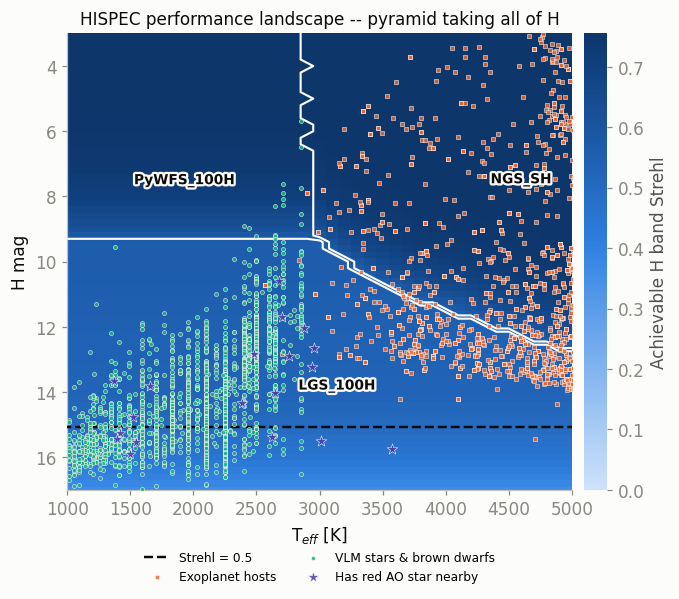

In [13]:
def plot_landscape(ls, ax=None, populations=None, vmax=None, strehl_thresh=None,
                   temp_xlim=(1000, 5000), mag_ylim=(17, 3), title=None,
                   mag_overrides=None, colorbar=True, label_modes=True, legend=True):
    """
    The (Teff, magnitude) landscape for one AO mode suite.

    inputs
    ------
    ls : Landscape
    populations : dict, optional
        {key: (teff, mag)} for the keys in POP_STYLE
    vmax : float, optional
        top of the Strehl colour scale; pass the same value across panels to
        make them comparable
    strehl_thresh : float, optional
        draw a dashed contour at this Strehl
    mag_ylim : tuple
        (faint, bright) -- inverted, since magnitudes are plotted
    mag_overrides : dict, optional
        {mode: mag} to pin a region label's y position

    output
    ------
    (ax, mesh)
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 5.6))
    fig = ax.figure
    vmax = float(np.nanmax(ls.best_strehl)) if vmax is None else vmax

    mesh = ax.pcolormesh(bin_edges_from_centers(ls.temps),
                         bin_edges_from_centers(ls.mags), ls.best_strehl.T,
                         cmap=STREHL_CMAP, vmin=0, vmax=vmax,
                         shading='flat', rasterized=True)

    # Region boundaries as hairlines in the surface colour -- the gap the mark
    # spec asks for between adjacent fills.
    if len(ls.ao_modes) > 1:
        ax.contour(ls.temps, ls.mags, ls.best_idx.T.astype(float),
                   levels=np.arange(len(ls.ao_modes) - 1) + 0.5,
                   colors=SURFACE, linewidths=1.4, zorder=10)

    if strehl_thresh is not None:
        ax.contour(ls.temps, ls.mags, ls.best_strehl.T, levels=[strehl_thresh],
                   colors=INK, linewidths=1.6, linestyles='dashed', zorder=12)
        ax.plot([], [], linestyle='dashed', color=INK, lw=1.6,
                label='Strehl = %g' % strehl_thresh)

    if label_modes:
        label_regions(ax, ls, mag_ylim=sorted(mag_ylim), mag_overrides=mag_overrides,
                      fontsize=9, fontweight='bold')
    if populations:
        draw_populations(ax, populations)

    ax.set_xlim(*temp_xlim)
    ax.set_ylim(*mag_ylim)
    ax.set_xlabel('T$_{eff}$ [K]')
    ax.set_ylabel('%s mag' % ls.band)
    ax.set_title(title or ', '.join(ls.ao_modes), fontsize=11, color=INK)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

    if colorbar:
        cb = fig.colorbar(mesh, ax=ax, pad=0.02)
        cb.set_label('Achievable %s band Strehl' % ls.band, color=INK_2)
        cb.outline.set_visible(False)
    # Below the axes, not inside: the populations fill the plane, so an inset
    # legend lands on top of the data it is labelling.
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.11),
                  ncol=2, frameon=False)
    return ax, mesh


ax, _ = plot_landscape(landscapes['Pyramid 100H'], populations=populations, vmax=VMAX,
                       strehl_thresh=0.5, mag_overrides={'PyWFS_100H': 7.5},
                       title='HISPEC performance landscape -- pyramid taking all of H')
ax.figure.tight_layout()

## 8. Comparing the suites

Same colour scale on every panel, so the fills are directly comparable: a
panel that is paler over the cool half of the plane is a suite that leaves
those targets worse corrected.

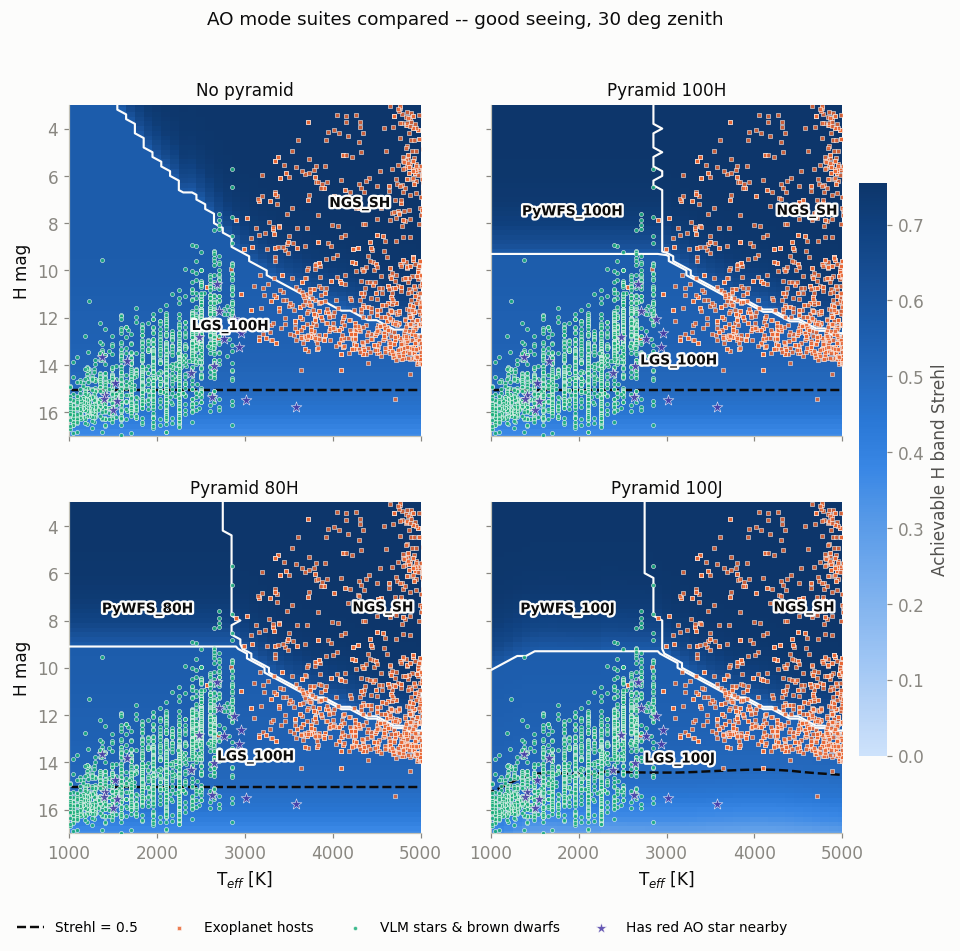

In [14]:
def plot_case_grid(landscapes, populations=None, ncols=2, vmax=None, strehl_thresh=0.5,
                   temp_xlim=(1000, 5000), mag_ylim=(17, 3), mag_overrides=None):
    "One landscape panel per case, on a shared Strehl scale and one shared colorbar."
    names = list(landscapes)
    ncols = min(ncols, len(names))
    nrows = int(np.ceil(len(names) / ncols))
    if vmax is None:
        vmax = max(float(np.nanmax(l.best_strehl)) for l in landscapes.values())

    fig, axs = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.3 * nrows),
                            sharex=True, sharey=True, squeeze=False)
    mesh = None
    for ax, name in zip(axs.ravel(), names):
        _, mesh = plot_landscape(landscapes[name], ax=ax, populations=populations,
                                 vmax=vmax, strehl_thresh=strehl_thresh,
                                 temp_xlim=temp_xlim, mag_ylim=mag_ylim, title=name,
                                 mag_overrides=mag_overrides, colorbar=False, legend=False)
        ax.set_xlabel('')
        ax.set_ylabel('')
    for ax in axs.ravel()[len(names):]:
        ax.set_visible(False)

    for ax in axs[-1]:
        if ax.get_visible():
            ax.set_xlabel('T$_{eff}$ [K]')
    band = next(iter(landscapes.values())).band
    for ax in axs[:, 0]:
        ax.set_ylabel('%s mag' % band)

    cb = fig.colorbar(mesh, ax=axs, pad=0.02, fraction=0.035)
    cb.set_label('Achievable %s band Strehl' % band, color=INK_2)
    cb.outline.set_visible(False)

    handles, labels = axs[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False,
                   bbox_to_anchor=(0.44, -0.01), fontsize=9)
    fig.suptitle('AO mode suites compared -- %s seeing, %g deg zenith'
                 % (sim.atmosphere.seeing_set, sim.zenith_angle), fontsize=12, color=INK)
    return fig, axs


_ = plot_case_grid(landscapes, populations=populations, vmax=VMAX,
                   mag_overrides={'PyWFS_100H': 7.5, 'PyWFS_80H': 7.5, 'PyWFS_100J': 7.5})

## 9. What each suite buys you

The difference between two suites is a **signed** quantity, so it takes the
diverging ramp: blue where the suite gains Strehl over the baseline, red where
it loses, neutral gray where nothing changes. The scale is symmetric about
zero -- otherwise "no change" would not sit on the neutral colour.

Only the region where the two suites pick *different* modes can be non-zero,
so this reads directly as "where does the extra mode actually get used, and by
how much".

Pyramid 100H   peak +0.190 / +0.000   helps over 12% of the plane, hurts over  0%
Pyramid 80H    peak +0.190 / +0.000   helps over 11% of the plane, hurts over  0%
Pyramid 100J   peak +0.233 / -0.098   helps over 14% of the plane, hurts over 16%


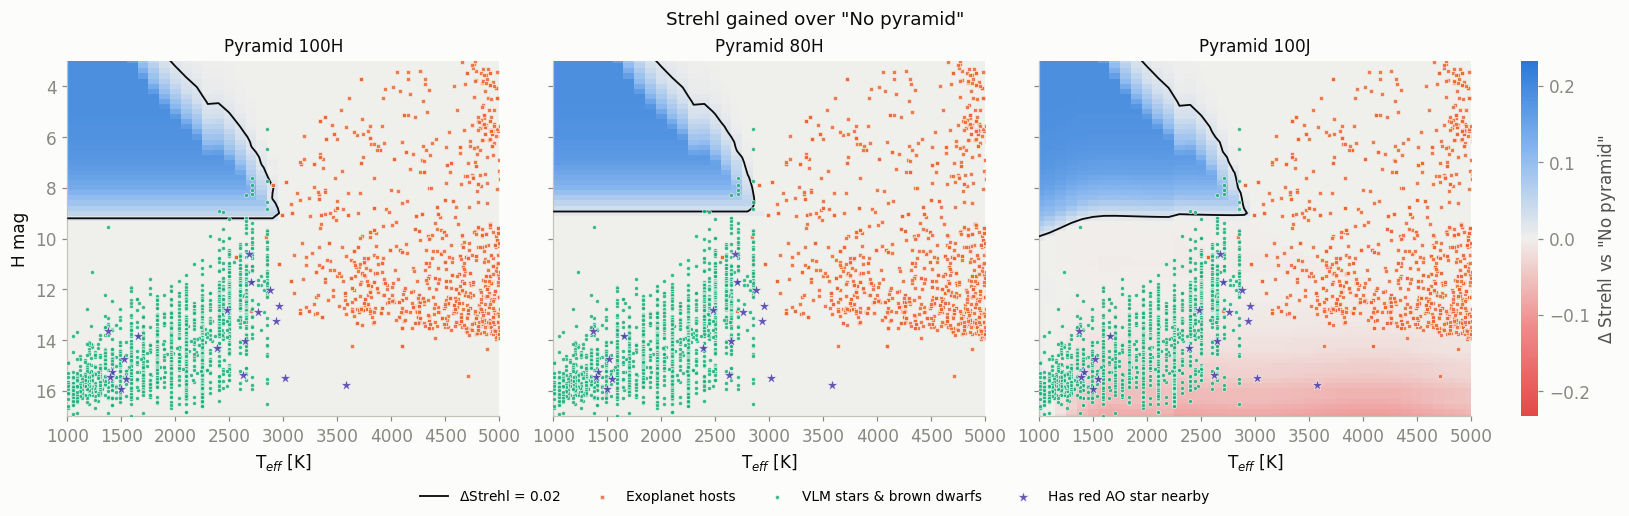

In [15]:
def plot_strehl_delta(ls, ls_ref, ax=None, populations=None, vlim=None, level=0.02,
                      temp_xlim=(1000, 5000), mag_ylim=(17, 3), title=None,
                      colorbar=True, legend=True, ref_name='baseline'):
    "Strehl gained by ls over ls_ref, on the diverging ramp. Returns (ax, mesh, delta)."
    if not (np.array_equal(ls.temps, ls_ref.temps) and np.array_equal(ls.mags, ls_ref.mags)):
        raise ValueError('the two landscapes must share their Teff and magnitude grids')
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 5.6))
    fig = ax.figure

    delta = ls.best_strehl - ls_ref.best_strehl
    if vlim is None:
        vlim = float(np.nanmax(np.abs(delta)))
    vlim = vlim or 1e-9

    mesh = ax.pcolormesh(bin_edges_from_centers(ls.temps),
                         bin_edges_from_centers(ls.mags), delta.T,
                         cmap=DELTA_CMAP, vmin=-vlim, vmax=vlim,
                         shading='flat', rasterized=True)
    # Outline where the gain is real rather than rounding.
    if np.nanmax(delta) > level > np.nanmin(delta):
        ax.contour(ls.temps, ls.mags, delta.T, levels=[level], colors=INK,
                   linewidths=1.2, zorder=12)
        ax.plot([], [], color=INK, lw=1.2, label='$\\Delta$Strehl = %g' % level)

    if populations:
        draw_populations(ax, populations)

    ax.set_xlim(*temp_xlim)
    ax.set_ylim(*mag_ylim)
    ax.set_xlabel('T$_{eff}$ [K]')
    ax.set_ylabel('%s mag' % ls.band)
    ax.set_title(title or 'Strehl gained', fontsize=11, color=INK)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    if colorbar:
        cb = fig.colorbar(mesh, ax=ax, pad=0.02)
        cb.set_label('$\\Delta$ Strehl vs %s' % ref_name, color=INK_2)
        cb.outline.set_visible(False)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.11),
                  ncol=2, frameon=False)
    return ax, mesh, delta


others = [n for n in landscapes if n != BASELINE_CASE]
ref = landscapes[BASELINE_CASE]
VLIM = max(float(np.nanmax(np.abs(landscapes[n].best_strehl - ref.best_strehl)))
           for n in others) or 1e-9

fig, axs = plt.subplots(1, len(others), figsize=(4.9 * len(others), 4.6),
                        sharex=True, sharey=True, squeeze=False, layout='constrained')
mesh = None
for ax, name in zip(axs[0], others):
    _, mesh, d = plot_strehl_delta(landscapes[name], ref, ax=ax, populations=populations,
                                   vlim=VLIM, title=name, colorbar=False, legend=False)
    if ax is not axs[0, 0]:
        ax.set_ylabel('')
    won, lost = d > 0.02, d < -0.02
    print('%-14s peak %+.3f / %+.3f   helps over %2.0f%% of the plane, hurts over %2.0f%%'
          % (name, d.max(), d.min(), 100 * won.mean(), 100 * lost.mean()))

cb = fig.colorbar(mesh, ax=axs, pad=0.02, fraction=0.035)
cb.set_label('$\\Delta$ Strehl vs "%s"' % BASELINE_CASE, color=INK_2)
cb.outline.set_visible(False)

handles, labels = axs[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='outside lower center', ncol=len(labels),
               frameon=False, fontsize=9)
_ = fig.suptitle('Strehl gained over "%s"' % BASELINE_CASE, fontsize=12, color=INK)

## 10. How many real targets does it move?

A Strehl map is only interesting in proportion to the targets sitting on it.
The landscape is sampled at each catalogue target's own (T$_{eff}$, magnitude)
and summarised per population.

A single Strehl threshold turns out to be a blunt instrument here: every suite
contains an LGS mode, whose high-order correction barely depends on the guide
star, so essentially everything brighter than the magnitude cut clears 0.5. The
**median** and the **10th percentile** (the badly-corrected tail, which is what
a new mode is meant to rescue) are what separate the suites.

In [16]:
def summarise_targets(landscapes, populations, mag_max=15, thresh=0.6):
    "Achievable Strehl at each population's targets, per suite."
    rows = []
    for pop_key, (teff, mag) in populations.items():
        teff, mag = np.asarray(teff, float), np.asarray(mag, float)
        keep = np.isfinite(teff) & np.isfinite(mag) & (mag < mag_max)
        for name, ls in landscapes.items():
            s = ls.strehl_at(teff[keep], mag[keep])
            s = s[np.isfinite(s)]
            rows.append({'population': POP_STYLE[pop_key]['label'], 'suite': name,
                         'on grid': len(s),
                         'median S': np.median(s) if len(s) else np.nan,
                         '10th pct S': np.percentile(s, 10) if len(s) else np.nan,
                         'S > %g' % thresh: int((s > thresh).sum())})
    return pd.DataFrame(rows).set_index(['population', 'suite']).round(3)


summary = None
if populations:
    summary = summarise_targets(landscapes, populations)
    display(summary)
else:
    print('no population catalogues available, skipping')

on grid  median S  10th pct S  S > 0.6
population               suite                                               
Exoplanet hosts          No pyramid       3365     0.643       0.532     1900
                         Pyramid 100H     3365     0.643       0.532     1900
                         Pyramid 80H      3365     0.643       0.532     1900
                         Pyramid 100J     3365     0.643       0.525     1900
VLM stars & brown dwarfs No pyramid       1240     0.535       0.509        6
                         Pyramid 100H     1240     0.535       0.509       12
                         Pyramid 80H      1240     0.535       0.509        9
                         Pyramid 100J     1240     0.527       0.485       11
Has red AO star nearby   No pyramid         12     0.540       0.521        0
                         Pyramid 100H       12     0.540       0.521        0
                         Pyramid 80H        12     0.540       0.521        0
                         Pyramid 100J       12     0.533       0.503        0

And per target, the difference against the baseline: how many real targets each
suite actually improves, degrades, and by how much. These are the numbers that
go in a design review.

In [17]:
def compare_targets(landscapes, populations, baseline, mag_max=15, tol=0.02):
    "Per-target Strehl change vs the baseline suite, summarised per population."
    ref = landscapes[baseline]
    rows = []
    for pop_key, (teff, mag) in populations.items():
        teff, mag = np.asarray(teff, float), np.asarray(mag, float)
        keep = np.isfinite(teff) & np.isfinite(mag) & (mag < mag_max)
        s_ref = ref.strehl_at(teff[keep], mag[keep])
        for name, ls in landscapes.items():
            if name == baseline:
                continue
            d = ls.strehl_at(teff[keep], mag[keep]) - s_ref
            d = d[np.isfinite(d)]
            better, worse = d > tol, d < -tol
            rows.append({'population': POP_STYLE[pop_key]['label'], 'suite': name,
                         'improved': int(better.sum()), 'degraded': int(worse.sum()),
                         'median gain (improved)': np.median(d[better]) if better.any() else 0.0,
                         'median loss (degraded)': np.median(d[worse]) if worse.any() else 0.0})
    return pd.DataFrame(rows).set_index(['population', 'suite']).round(3)


if populations:
    display(compare_targets(landscapes, populations, BASELINE_CASE))

improved  degraded  \
population               suite                              
Exoplanet hosts          Pyramid 100H         0         0   
                         Pyramid 80H          0         0   
                         Pyramid 100J         0         0   
VLM stars & brown dwarfs Pyramid 100H        12         0   
                         Pyramid 80H          7         0   
                         Pyramid 100J         9       197   
Has red AO star nearby   Pyramid 100H         0         0   
                         Pyramid 80H          0         0   
                         Pyramid 100J         0         1   

                                       median gain (improved)  \
population               suite                                  
Exoplanet hosts          Pyramid 100H                   0.000   
                         Pyramid 80H                    0.000   
                         Pyramid 100J                   0.000   
VLM stars & brown dwarfs Pyramid 100H                   0.059   
                         Pyramid 80H                    0.086   
                         Pyramid 100J                   0.067   
Has red AO star nearby   Pyramid 100H                   0.000   
                         Pyramid 80H                    0.000   
                         Pyramid 100J                   0.000   

                                       median loss (degraded)  
population               suite                                 
Exoplanet hosts          Pyramid 100H                   0.000  
                         Pyramid 80H                    0.000  
                         Pyramid 100J                   0.000  
VLM stars & brown dwarfs Pyramid 100H                   0.000  
                         Pyramid 80H                    0.000  
                         Pyramid 100J                  -0.026  
Has red AO star nearby   Pyramid 100H                   0.000  
                         Pyramid 80H                    0.000  
                         Pyramid 100J                  -0.023

## 11. Saving

One self-describing `.npz` per suite, with the axes travelling alongside the
array so a reader does not have to reconstruct the temperature grid from a
filename.

In [18]:
OUT = os.path.join(_root, 'examples', 'output')
os.makedirs(OUT, exist_ok=True)

path = None
for name, ls in landscapes.items():
    slug = name.lower().replace(' ', '_').replace('+', 'plus')
    path = os.path.join(OUT, 'ao_landscape_%s_%s_%gdeg.npz'
                        % (slug, sim.atmosphere.seeing_set, sim.zenith_angle))
    ls.save(path)
    print('wrote %s' % os.path.relpath(path, _root))

again = Landscape.load(path)   # round-trip check on the last one
print('\nreloaded: modes %s, %d temps, %d mags, strehl %s'
      % (again.ao_modes, len(again.temps), len(again.mags), again.strehl.shape))

wrote examples/output/ao_landscape_no_pyramid_good_30deg.npz
wrote examples/output/ao_landscape_pyramid_100h_good_30deg.npz
wrote examples/output/ao_landscape_pyramid_80h_good_30deg.npz
wrote examples/output/ao_landscape_pyramid_100j_good_30deg.npz

reloaded: modes ['NGS_SH', 'PyWFS_100J', 'LGS_100J', 'LGS_STRAP'], 51 temps, 101 mags, strehl (51, 4, 101)


## 12. What changed in the port

From `_pyramid_sims/plot_ao_landscape.py`. The specsim calls were updated for
the refactor branch (`load_object`/`fill_data` -> `simulate_from_config`,
`wfe_tools` -> `aosystem`/`functions`, `get_band_mag2` ->
`Star.magnitude_in_band`), and beyond that:

**Correctness**

- Guide stars fainter than the WFE table's last row now get Strehl 0 instead
  of the mag-23 row's value. The old code clamped both ends, which quietly
  credited a mag-30 V guide star with mag-23 performance -- exactly the regime
  cool dwarfs land in after the colour shift.
- Strehl uses `calc_strehl_marechal`, which is what `AOSystem.select()` uses on
  the refactor branch, so the landscape agrees with the mode specsim actually
  picks under `mode='auto'`. The old script used the extended Marechal
  `calc_strehl`; both still live in `specsim.functions`.

**Structure**

- `compute_landscape()` returns a `Landscape` instead of writing four `.npy`
  files whose grids lived only in the filename. The old
  `get_best_aomode`/`plot_planets_ao_modes` pair disagreed about those names
  (`best_ao_mode2_Hmag_mags.npy` was read but never written), and the
  temperature list in the filename omitted 2700 K even though it was in the
  grid. Axes now travel with the data.
- Bandpasses are built once per *band* rather than once per mode, and the star
  is built straight from `sim.star.params` rather than through
  `sim.set_star()`, which would re-run AO mode selection and reload the fiber
  coupling at every temperature.
- The full Strehl cube is kept, not just the winner, so the 1-D cuts in
  section 5 and the differences in section 9 come free.

**Resolution**

- The magnitude axis is decoupled from the WFE tables' 24-row grid: WFE is
  interpolated at whatever grid you ask for (0.2 mag here). The Teff axis is
  100 K rather than the original eight hand-picked temperatures.

**Encoding** -- see the palette note in section 1. The fill went from a flat
categorical colour per mode to the sequential Strehl ramp, with mode identity
moved to direct labels and boundaries, so it survives the six-mode comparison
in section 8 and never leans on colour alone.

### Things to try

- `SEEING` / `ZENITH` in section 2: the WFE tables are indexed by both, and the
  mode crossovers move with them.
- `SCI_BAND`: a K-band landscape has a different Strehl scaling *and* a
  different colour shift, so the crossovers move both ways.
- Your own suites in `CASES`, and a different `BASELINE_CASE` to difference
  against.
- `sim.set_ao(mode=..., mag=..., mag_band=...)` plus `sim.snr()` to turn a
  point on this map into an actual spectrum -- see `examples/ao_mode_cases.py`.